In [22]:
import math
import os
import random
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics
from sklearn.model_selection import train_test_split
 
import seaborn as sns
import matplotlib.pyplot as plt
import sys
from scipy import stats
from sklearn.impute import SimpleImputer
import re
from sklearn.metrics import classification_report, accuracy_score
from sklearn.datasets import make_classification

from sklearn.base import clone    
from itertools import combinations
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import SequentialFeatureSelector

from sklearn.pipeline import Pipeline

### Diccionario de Datos: Predicción de Deserción Escolar

| Variable | Tipo | Descripción |
| :--- | :--- | :--- |
| **Marital status** | Categórica | 1 – single 2 – married 3 – widower 4 – divorced 5 – facto union 6 – legally separated |
| **Application mode** | Categórica | Método de ingreso (ej. examen de estado, transferencia, etc.). |
| **Course** | Categórica | Código del programa académico. |
| **Attendance** | Binaria | 1 – day time 0 – evening |
| **Previous qualification** | Categórica | Calificación obtenida en la educación secundaria. |
| **Scholarship holder** | Binaria | Si el estudiante posee beca (1: sí, 0: no). |
| **Debtor** | Binaria | Si el estudiante tiene deudas de matrícula (1: sí, 0: no). |
| **Tuition fees up to date** | Binaria | Si el pago de cuotas está al día (1: sí, 0: no). |
| **Curricular units 1st sem (grade)** | Numérica | Promedio de notas en el primer semestre (0 a 20). |
| **Unemployment rate** | Numérica | Tasa de desempleo regional. |
| **Target** | Categórica | **Clase de salida (Dropout, Enrolled, Graduate)** |

In [23]:
df = pd.read_csv('../../datasets/StudentsPerformance.csv', sep=';')

¿Hay nulos?

In [24]:
df.isnull().sum()

Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance\t                      0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder                                0
Age at enrol

Son 3 clases, transformo una binaria y sea un problema mas simple.

In [25]:
df["Target"] = df["Target"].replace({
    "Graduate": "NoDropout",
    "Enrolled": "NoDropout"
})



Tengo un problema con el target, vamos a transformarlo con LabelEncoder

In [26]:
le = LabelEncoder()
df["Target"] = le.fit_transform(df["Target"])

In [27]:
le.classes_

array(['Dropout', 'NoDropout'], dtype=object)

Me quedo con algunas columnas. ¿Para poder hacer mas rápida la demostración?  
Un poco si, pero también un poco con la intension de ampliar el efecto.

In [28]:
fields =['Marital status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance\t', 'Previous qualification',
       'Previous qualification (grade)', 'Nacionality',
       "Mother's qualification", "Father's qualification",
       "Mother's occupation", "Father's occupation", "Admission grade",
       'Displaced', 'Educational special needs', 'Debtor',
       'Tuition fees up to date', 'Gender', 'Scholarship holder',
       'Age at enrollment', 'International',
       #'Curricular units 1st sem (credited)',
       #'Curricular units 1st sem (enrolled)',
       #'Curricular units 1st sem (evaluations)',
       #'Curricular units 1st sem (approved)',
       #'Curricular units 1st sem (grade)',
       #'Curricular units 1st sem (without evaluations)',
       #'Curricular units 2nd sem (credited)',
       #'Curricular units 2nd sem (enrolled)',
       #'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       #'Curricular units 2nd sem (grade)',
       #'Curricular units 2nd sem (without evaluations)', 'Unemployment rate',
       'Inflation rate', 'GDP', 'Target']

df = df[fields]

Analizo el balanceo de clases

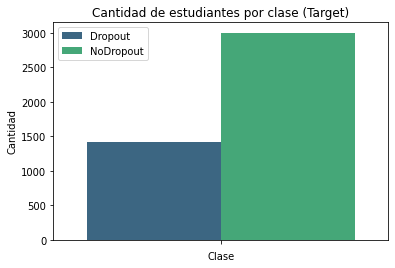

In [29]:
conteo_target = df["Target"].value_counts().sort_index()
nombres_clases = le.inverse_transform(conteo_target.index)

ax = sns.barplot(hue=nombres_clases, y=conteo_target.values, palette="viridis")
ax.set_title("Cantidad de estudiantes por clase (Target)")
ax.set_xlabel("Clase")
ax.set_ylabel("Cantidad")

plt.show()

La diferencia no es tan marcada, pero cuidado que KNN es pro-mayoría

Es KNN, los datos deben ser escalados.

In [30]:
X = df.drop(columns=["Target"])
y = df["Target"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Usemos el modelo con todas las características y k = 11

In [31]:
k = 11
scaler = MinMaxScaler().set_output(transform="pandas")
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
model = KNeighborsClassifier(n_neighbors=k)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
balanced_accuracy = metrics.balanced_accuracy_score(y_test, y_pred)
print(f"Balanced Accuracy Crudo: {balanced_accuracy:.4f}")

Balanced Accuracy Crudo: 0.7250


¿Se podrá mejorar? ¿Tengo variables que no tienen capacidad predictiva y están molestando?  
Hagamos un feature selection manual. Dudo entre "permutation features" o algo como "Secuencial Background Selection". Como mi modelo es KNN y es "lazy" entonces la diferencia entre uno y otro no sera tan marcada, me inclino por un "Secuencial Background Selection".  
Seleccionemos solo 3 características.

In [32]:
n_features = 3
class SBS():
    def __init__(self, estimator, k_features, scoring=metrics.balanced_accuracy_score,
                 test_size=0.25, random_state=1):
        self.scoring = scoring
        self.estimator = clone(estimator)
        self.k_features = k_features
        self.test_size = test_size
        self.random_state = random_state

    def fit(self, X, y):
        # Observar que puede estar remuestreando la muestra de entrenamiento original
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=self.test_size, random_state=self.random_state, stratify=y
        )

        dim = X_train.shape[1]
        self.indices_ = tuple(range(dim))
        self.subsets_ = [self.indices_]
        score = self._calc_score(X_train, y_train, X_test, y_test, self.indices_)
        self.scores_ = [score]

        while dim > self.k_features:
            scores = []
            subsets = []

            for p in combinations(self.indices_, r=dim - 1):
                score = self._calc_score(X_train, y_train, X_test, y_test, p)
                scores.append(score)
                subsets.append(p)

            best = np.argmax(scores)
            self.indices_ = subsets[best]
            self.subsets_.append(self.indices_)
            dim -= 1

            self.scores_.append(scores[best])
        self.k_score_ = self.scores_[-1]

        return self

    def transform(self, X):
        return X.iloc[:, list(self.indices_)]

    def _calc_score(self, X_train, y_train, X_test, y_test, indices):
        self.estimator.fit(X_train.iloc[:, list(indices)], y_train)
        y_pred = self.estimator.predict(X_test.iloc[:, list(indices)])
        score = self.scoring(y_test, y_pred)
        return score
    
    def score(self, X, y):
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=self.test_size, random_state=self.random_state, stratify=y
        )
        model = clone(self.estimator)
        model.fit(X_train.iloc[:, list(self.indices_)], y_train)
        y_pred = model.predict(X_test.iloc[:, list(self.indices_)])
        score = self.scoring(y_test, y_pred)
        return score
    
    def base_score(self, X, y):
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=self.test_size, random_state=self.random_state, stratify=y
        )
        model = clone(self.estimator)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        score = self.scoring(y_test, y_pred)
        return score


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
mme = MinMaxScaler().set_output(transform="pandas") #transform_output en versiones anteriores :(
#ojo con la fuga
X_train = mme.fit_transform(X_train)
X_test = mme.transform(X_test)

model = KNeighborsClassifier(n_neighbors=k)
SBS_model = SBS(model, k_features=n_features)
SBS_model.fit(X_train, y_train)

# IMPORTANTE: los índices de SBS corresponden a X (sin Target), no a df
final_features_sbs = X.columns[list(SBS_model.indices_)]
df_custom_sbs = X.loc[:, final_features_sbs]
print("Features SBS:", list(final_features_sbs))

Features SBS: ['Admission grade', 'Tuition fees up to date', 'Curricular units 2nd sem (approved)']


Hagámoslo ahora con sklearn

In [ ]:
#Vuelvo a crear el modelo solo para que no queden dudas...
model = KNeighborsClassifier(n_neighbors=k, weights='distance')

plsfs = Pipeline([
    ('scaler', MinMaxScaler()),
    ('selector', SequentialFeatureSelector(model, direction='backward', n_features_to_select=n_features, scoring='balanced_accuracy')),
    ('classifier', model)
])

plsfs.fit(X_train, y_train)
final_features_idx = plsfs.named_steps['selector'].get_support(indices=True)
final_features_sfs = X.columns[final_features_idx]
print("Selected features:", final_features_sfs)

Selected features: Index(['Course', 'Tuition fees up to date',
       'Curricular units 2nd sem (approved)'],
      dtype='object')


¿Porque pueden existir diferencia entre mi implementación y la de sklearn? Sklearn usa validación cruzada interna y es mas robusta, mi versión pudo caer en un problema de muestra puntual o típicamente un "casi empate" entre dos variables, deberíamos confiar mas si hubo una costosa validación cruzada.

In [35]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
mme = MinMaxScaler().set_output(transform="pandas") #transform_output en versiones anteriores :(
#ojo con la fuga
X_train = mme.fit_transform(X_train)
X_test = mme.transform(X_test)


model = KNeighborsClassifier(n_neighbors=k, weights='distance')
model.fit(X_train, y_train)
balanced_accuracy = metrics.balanced_accuracy_score(y_test, model.predict(X_test))
print(f"Balanced Accuracy Crudo: {balanced_accuracy:.4f}")

#model = KNeighborsClassifier(n_neighbors=k, weights='distance')
model.fit(X_train.loc[:, final_features_sbs], y_train)
balanced_accuracy_sbs = metrics.balanced_accuracy_score(y_test, model.predict(X_test.loc[:, final_features_sbs]))
print(f"Balanced Accuracy con SBS: {balanced_accuracy_sbs:.4f}")

#model = KNeighborsClassifier(n_neighbors=k, weights='distance')
model.fit(X_train.loc[:, final_features_sfs], y_train)
balanced_accuracy_sfs = metrics.balanced_accuracy_score(y_test, model.predict(X_test.loc[:, final_features_sfs]))
print(f"Balanced Accuracy con SequentialFeatureSelector: {balanced_accuracy_sfs:.4f}")


Balanced Accuracy Crudo: 0.7285
Balanced Accuracy con SBS: 0.7819
Balanced Accuracy con SequentialFeatureSelector: 0.7924


TODO: aun no tengo claro cuantos datos se necesitan para modelar el fenómeno. ¿Sera una buena idea balancear clases castigando la clase mas numerosa? No se, implementar y verificar.